In [242]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [245]:
kplus_Calbindin = 75 # μm^-1s^-1
kplus_EGTA = 1.5 # μm^-1s^-1
kplus_BAPTA = 600 # μm^-1s^-1
# B_conc_infty = 2 # 2 - 350 μM
Ca_conc_infty = 0.1 # μM
R = 8.31 # J/(mol * k)
T = 300 # K
delta = 0.0733
f_c = 0.01
f_m = 0.0003
K_1 = 6 # μM
K_2 = 0.38 # μM
k_X = 0.008 # s^-1
L = 50
p_1 = 0.1 # mV^-1
p_2 = 0.016 # mV^-1
p_3 = 0.05 # mV^-1
V_MCU = 0.0006 # μMs^-1
V_NCX = 0.35 # 0.35 μMs^-1
z_Ca = 2
F = 96485 # C/mol
Na_conc_out = 1400 # mM
Na_conc_in = 20 # mM
P_Ca = 9.105 * (10**-11)
V_m = -0.07 # V
V_neuron = 523.6 # μm^3
V_neuron_L = V_neuron * 0.000000000000001 # L
D_leak = 0.11 # s^-1
D_chan = 6 # s^-1
Pmax_R = 0.9 # μMs^-1
K = 0.1 # μM
C_1 = 0.182 # μM
C_p = 1.8 # μM mV^-1t
D = 200 # 200-300 μm^2s^-1

A_neuron = 350000 # μm^2

In [246]:
def dParams(t, C_vec):
    C_cyto = C_vec[0]
    C_ER = C_vec[1]
    C_mito = C_vec[2]
    Mito_membrane_voltage = C_vec[3]

    
    J_MCU = V_MCU * (C_cyto/K_1)*np.power(1+C_cyto/K_1,3) / ( np.power(1+C_cyto/K_1,3) + L/np.power(1+C_cyto/K_2,2.3) ) * np.exp(p_1*Mito_membrane_voltage)
    J_NCX = V_NCX * C_mito / C_cyto * np.exp(p_2*Mito_membrane_voltage)
    J_X = k_X * (C_cyto - C_mito) * np.exp(p_3*Mito_membrane_voltage)
    
    J_mito = J_MCU + J_X - J_NCX
    C_0 = C_1 * C_ER + C_cyto

    dC_ER = Pmax_R * (C_cyto**2 / (C_cyto**2 + K**2)) - (1+C_1)*(D_leak + D_chan) * (C_0 / (1+C_1) - C_cyto)
    
    dC_cyto = (
        - dC_ER
        #- total_association_rate * B_conc_infty * (C_cyto-Ca2_conc_infty)
        - delta * J_mito
    )
    # + advection/diffusion terms

    dC_mito = f_m * J_mito

    #dMito_membrane_voltage = -(J_NCX + 2*J_MCU + 2*J_X) / C_p
    dMito_membrane_voltage = 0
    return np.array([dC_cyto, dC_ER, dC_mito, dMito_membrane_voltage])

In [247]:
# initial conditions / parameters
C_vec_0 = np.array([0.1, 0.6, 0.3, -0.04])
B_conc_infty = 2 # 2 - 350 μM
total_association_rate = kplus_Calbindin + kplus_EGTA + kplus_BAPTA

In [248]:
# integrate
t_span = [0,8]
dt = 0.01
t_eval = np.arange(t_span[0],t_span[1],dt)
sol = solve_ivp(dParams, t_span, C_vec_0, t_eval=t_eval)

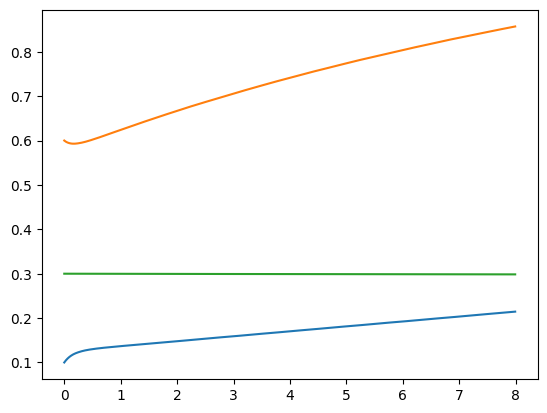

In [249]:
plt.plot(sol.t, sol.y[0])
plt.plot(sol.t, sol.y[1])
plt.plot(sol.t, sol.y[2])

In [259]:
def dParams(t, C_vec):
    Ca_cyto_wall = C_vec[0]
    Ca_cyto_ER = C_vec[1]
    Ca_cyto_mito = C_vec[2]
    BufferBound = C_vec[3]
    Ca_ER = C_vec[4]
    Ca_mito = C_vec[5]
    Mito_membrane_voltage = C_vec[6]
    
    
    J_MCU = V_MCU * (Ca_cyto_mito/K_1)*np.power(1+Ca_cyto_mito/K_1,3) / ( np.power(1+Ca_cyto_mito/K_1,3) + L/np.power(1+Ca_cyto_mito/K_2,2.3) ) * np.exp(p_1*Mito_membrane_voltage)
    J_NCX = V_NCX * Ca_mito / Ca_cyto_mito * np.exp(p_2*Mito_membrane_voltage)
    J_X = k_X * (Ca_cyto_mito - Ca_mito) * np.exp(p_3*Mito_membrane_voltage)
    
    J = J_MCU + J_X - J_NCX
    
    sigma_VGCC = (
        - P_Ca * z_Ca * F * V_m
        * (Ca_cyto_wall - Ca2_conc_infty * np.exp(z_Ca * F * V_m / R / T))
        / R / T / V_neuron_L
        / (1 - np.exp(z_Ca * F * V_m / R / T))
    )
    
    sigma_NCX = Ca2_conc_infty * (Na2_conc_in/Na2_conc_out)**3 * np.exp(F * V_m / R / T)
    
    dBufferBound = total_association_rate * B_conc_infty * (Ca_cyto_wall) - BufferBound * total_association_rate * B_conc_infty * Ca_conc_infty / f_c
    
    dCa_ER = (
        Pmax_R * (Ca_cyto_ER**2 / (Ca_cyto_ER**2 + K**2))
        - (1+C_1)*(D_leak + D_chan) * ((C_1 * Ca_ER + Ca_cyto_ER) / (1+C_1) - Ca_cyto_ER)
    )

    dCa_cyto_wall = (
        sigma_VGCC #+ sigma_NCX
        - dBufferBound
    )
    
    dCa_cyto_ER = (
        - dCa_ER
    )

    dCa_cyto_mito = (
        - delta * J
    )
    
    # + advection/diffusion terms
    
    dCa_mito = f_m * J
    
    #dMito_membrane_voltage = -(J_NCX + 2*J_MCU + 2*J_X) / C_p
    dMito_membrane_voltage = 0
    return np.array([dCa_cyto_wall, dCa_cyto_ER, dCa_cyto_mito, dBufferBound, dCa_ER, dCa_mito, dMito_membrane_voltage])

In [260]:
# initial conditions / parameters
C_vec_0 = np.array([0.1, 0.1, 0.1, 1.0, 0.6, 0.3, -0.04])
B_conc_infty = 2 # 2 - 350 μM
total_association_rate = kplus_Calbindin + kplus_EGTA + kplus_BAPTA

In [264]:
# integrate
t_span = [0,0.08]
dt = 0.01
t_eval = np.arange(t_span[0],t_span[1],dt)
sol = solve_ivp(dParams, t_span, C_vec_0, t_eval=t_eval)

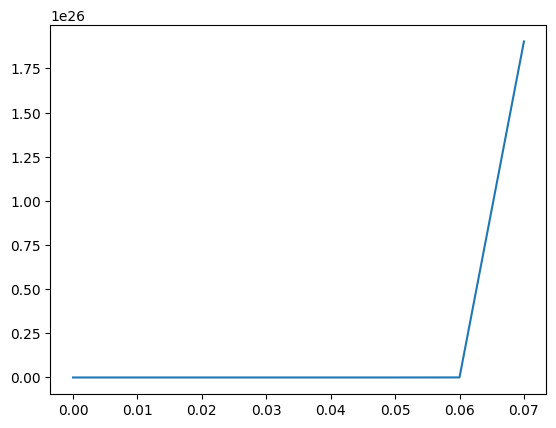

In [265]:
plt.plot(sol.t, sol.y[0])
#plt.plot(sol.t, sol.y[1])
#plt.plot(sol.t, sol.y[2])